<a href="https://colab.research.google.com/github/nrldalia/mini_project/blob/g---colab/E_Commerce_%26_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce & Retail Data Analysis

In [ ]:
import kagglehub
path = kagglehub.dataset_download("rajhkumarr/e-commerce-and-retail-supply-chain")

100%|██████████| 5.07M/5.07M [00:00<00:00, 122MB/s]

Extracting files...


In [ ]:
import pandas as pd
import numpy as np
from google.colab import auth
import gspread
from google.auth import default

In [ ]:
# 1. Authenticate user for Google Sheets API
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
import os
print(os.listdir(path))

['inventory_snapshot.csv', 'daily_inventory.csv', 'sales.csv', 'purchase_orders.csv', 'products.csv', 'suppliers.csv']


In [ ]:
csv_files = ['daily_inventory.csv', 'products.csv', 'suppliers.csv', 'sales.csv', 'inventory_snapshot.csv', 'purchase_orders.csv']
dfs = {}

for filename in csv_files:
    file_path = os.path.join(path, filename)
    df_name = filename.replace('.csv', '')
    dfs[df_name] = pd.read_csv(file_path)
    print(f"--- {df_name.replace('_', ' ').title()} ---")
    display(dfs[df_name].head())
    print('\n')


--- Daily Inventory ---


,snapshot_date,sku_id,current_stock,daily_sales,incoming_stock,warehouse_stock,retail_stock,amazon_allocated,tiktokshop_allocated,zalora_allocated,reorder_point,safety_stock
0,2016-01-01,SKU9310518635,29,0,1606,17,12,5,3,1,15,0
1,2016-01-01,SKU6955836996,29,0,2328,17,12,5,3,1,6,0
2,2016-01-01,SKU6171745695,35,0,2761,21,14,6,4,2,5,0
3,2016-01-01,SKU9112068923,2,0,3371,1,1,0,0,0,10,0
4,2016-01-01,SKU4171552432,24,0,2178,14,10,4,2,1,18,0




--- Products ---


,sku_id,product_name,category,sub_category,brand,product_type,size_label,launch_date,shelf_life_months,parent_sku,default_price,primary_supplier_id,is_active,country_of_origin,online_only,avg_rating,rating_count,is_discontinued
0,SKU9310518635,Garnier Sunscreen 50ml,Beauty,Skincare & Cosmetics,Garnier,Sunscreen,50ml,2019-04-22,18.0,SKU5304202933,17.74,200139,True,UK,False,3.93,73,False
1,SKU6955836996,Adidas Running Shoes Standard,Sports & Lifestyle,Sports Gear,Adidas,Running Shoes,Standard,2016-08-13,NaN,NaN,44.64,200856,True,CN,False,3.26,485,False
2,SKU6171745695,Puma Gym Towel Standard,Sports & Lifestyle,Sports Gear,Puma,Gym Towel,Standard,2017-01-26,NaN,NaN,63.71,200983,True,JP,False,3.44,329,False
3,SKU9112068923,Samsung Power Bank 10000mAh,Electronics Accessories,Gadgets,Samsung,Power Bank,10000mAh,2019-04-21,NaN,NaN,49.10,200439,True,AU,False,4.33,183,False
4,SKU4171552432,Sony USB Charger 33W,Electronics Accessories,Gadgets,Sony,USB Charger,33W,2016-04-24,NaN,SKU1416947255,41.20,200991,True,US,False,4.48,56,False




--- Suppliers ---


...

,sale_id,order_id,date,sku_id,channel,quantity,unit_price,promo_flag,discount_pct,event_name,customer_segment_id,customer_segment,device_type,payment_method,shipping_fee,voucher_amount,net_revenue,returned_flag,quarter_bucket,month
0,97746642,ORD97746642,2019-04-22,SKU9310518635,Amazon,1,17.74,0,0.0,NaN,2,premium,mobile_app,e_wallet,0.23,0.0,17.97,0,2019Q2,2019-04-01
1,98635846,ORD98635846,2019-04-25,SKU9310518635,Amazon,1,17.74,0,0.0,NaN,1,value,mobile_app,debit_card,1.62,0.0,19.36,0,2019Q2,2019-04-01
2,12607411,ORD12607411,2019-04-27,SKU9310518635,Zalora,1,17.74,0,0.0,NaN,1,value,mobile_app,debit_card,3.84,0.0,21.58,0,2019Q2,2019-04-01
3,90411177,ORD90411177,2019-04-28,SKU9310518635,TikTokShop,1,17.74,0,0.0,NaN,2,premium,mobile_web,e_wallet,2.61,0.0,20.35,0,2019Q2,2019-04-01
4,40822201,ORD40822201,2019-04-28,SKU9310518635,Zalora,2,17.74,0,0.0,NaN,1,value,mobile_app,credit_card,1.26,0.0,36.74,0,2019Q2,2019-04-01




--- Inventory Snapshot ---


,snapshot_date,sku_id,current_stock,incoming_stock,stock_age_days,warehouse_stock,retail_stock,amazon_allocated,tiktokshop_allocated,zalora_allocated,reorder_point,safety_stock,backorder_qty,opening_buffer
0,2022-12-31,SKU9310518635,360,0,674,280,80,59,41,30,28,6,0,29
1,2022-12-31,SKU6955836996,768,0,1165,497,271,167,59,67,34,4,0,29
2,2022-12-31,SKU6171745695,915,0,1082,570,345,187,77,88,41,6,5,35
3,2022-12-31,SKU9112068923,525,0,675,338,187,70,34,65,67,14,0,2
4,2022-12-31,SKU4171552432,1098,0,1221,556,542,90,76,106,22,3,0,24




--- Purchase Orders ---


,po_id,sku_id,supplier_id,po_date,promised_delivery_date,delivery_date,order_qty,unit_cost,shipping_mode,status,incoterm,currency,freight_cost,duty_cost
0,PO03732421,SKU9310518635,200139,2019-05-22,2019-06-12,2019-06-18,106,13.65,Air,delivered,EXW,EUR,7.01,10.44
1,PO72647743,SKU9310518635,200139,2019-06-03,2019-06-24,2019-06-27,159,11.37,Air,delivered,EXW,EUR,25.97,17.82
2,PO41745551,SKU9310518635,200139,2019-09-03,2019-09-24,2019-09-19,154,12.03,Air,delivered,EXW,EUR,8.51,16.78
3,PO95292145,SKU9310518635,200139,2019-12-04,2019-12-25,2019-12-21,94,14.15,Air,delivered,EXW,EUR,18.91,6.70
4,PO94595741,SKU9310518635,200139,2020-03-04,2020-03-25,2020-03-25,90,11.42,Air,delivered,EXW,EUR,20.69,6.11


### Data Cleaning

This section performs initial data cleaning steps on each loaded DataFrame:

1.  **Duplicate Rows**: Identify any exact duplicate rows.
2.  **Identifier Columns**: Drop rows where key identifier columns (e.g., `sku_id`, `sales_id`, `supplier_id`) have missing or blank values.
3.  **Quantity and Sales Data**: Filter out rows where numerical columns representing quantities, sales, or costs are missing, zero, or negative, as these are typically invalid data points for analysis.

In [ ]:
def clean_dataframe(df, df_name):
    print(f"\n--- Cleaning {df_name.replace('_', ' ').title()} ---")
    initial_rows = len(df)
    print(f"Initial number of rows: {initial_rows}")

    # Flag duplications instead of removing them
    df['is_duplicate'] = df.duplicated()
    duplicates_flagged = df['is_duplicate'].sum()
    if duplicates_flagged > 0:
        print(f"Flagged {duplicates_flagged} duplicate rows with 'is_duplicate' column.")

    # Columns to check for blanks/nulls in identifiers (critical for merges)
    id_cols_to_check = ['sku_id', 'sales_id', 'supplier_id', 'purchase_order_id']
    for col in id_cols_to_check:
        if col in df.columns:
            # Handle empty strings as NaN and then dropna
            initial_nulls = df[col].isnull().sum()
            df[col] = df[col].replace('', np.nan)
            df_before_drop = len(df)
            df = df.dropna(subset=[col])
            rows_dropped = df_before_drop - len(df)
            if initial_nulls > 0 or rows_dropped > 0:
                print(f"Dropped {rows_dropped} rows with null/blank '{col}'.")

    # Columns to check for non-positive values (sales, quantity, cost)
    numerical_cols_to_check = [
        'quantity_sold', 'order_quantity', 'daily_sales', 'current_stock',
        'stock_on_hand', 'price_per_unit', 'unit_cost', 'total_revenue', 'total_cost'
    ]
    for col in numerical_cols_to_check:
        if col in df.columns:
            # Convert to numeric if not already, coercing errors to NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')

            # Drop rows where these critical numerical columns are NaN after coercion
            initial_nulls_num = df[col].isnull().sum()
            df_before_drop = len(df)
            df = df.dropna(subset=[col])
            rows_dropped_num = df_before_drop - len(df)
            if initial_nulls_num > 0 or rows_dropped_num > 0:
                 print(f"Dropped {rows_dropped_num} rows with null '{col}' after numeric conversion.")

            # Filter out non-positive values
            non_positive_rows_before = len(df)
            df = df[df[col] > 0]
            non_positive_rows_dropped = non_positive_rows_before - len(df)
            if non_positive_rows_dropped > 0:
                print(f"Dropped {non_positive_rows_dropped} rows where '{col}' was <= 0.")

    # Check for nulls/blanks in 'product_name' or 'description' if they exist
    description_cols = ['product_name', 'description']
    for col in description_cols:
        if col in df.columns:
            initial_desc_nulls = df[col].isnull().sum()
            df[col] = df[col].replace('', np.nan)
            df_before_drop_desc = len(df)
            df = df.dropna(subset=[col])
            rows_dropped_desc = df_before_drop_desc - len(df)
            if initial_desc_nulls > 0 or rows_dropped_desc > 0:
                print(f"Dropped {rows_dropped_desc} rows with null/blank '{col}'.")

    final_rows = len(df)
    print(f"Final number of rows: {final_rows}")
    print(f"Total rows removed from {df_name.replace('_', ' ').title()}: {initial_rows - final_rows - duplicates_flagged}") # Adjusted for flagged duplicates
    print(f"Remaining missing values in {df_name.replace('_', ' ').title()}:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    return df

# Apply cleaning to all dataframes
cleaned_dfs = {name: clean_dataframe(df.copy(), name) for name, df in dfs.items()}


--- Cleaning Daily Inventory ---
Initial number of rows: 204560
Dropped 132251 rows where 'daily_sales' was <= 0.
Dropped 3331 rows where 'current_stock' was <= 0.
Final number of rows: 68978
Total rows removed from Daily Inventory: 135582
Remaining missing values in Daily Inventory:
Series([], dtype: int64)

--- Cleaning Products ---
Initial number of rows: 80
Final number of rows: 80
Total rows removed from Products: 0
Remaining missing values in Products:
shelf_life_months    54
parent_sku           70
dtype: int64

--- Cleaning Suppliers ---
Initial number of rows: 25
Final number of rows: 25
Total rows removed from Suppliers: 0
Remaining missing values in Suppliers:
Series([], dtype: int64)

--- Cleaning Sales ---
Initial number of rows: 160131
Final number of rows: 160131
Total rows removed from Sales: 0
Remaining missing values in Sales:
event_name    150427
dtype: int64

--- Cleaning Inventory Snapshot ---
Initial number of rows: 80
Final number of rows: 80
Total rows removed 

### Cleaned DataFrames Information

Here's an overview of each DataFrame after the cleaning process, including the data types and non-null counts.

In [ ]:
for df_name, df in cleaned_dfs.items():
    print(f"\n--- {df_name.replace('_', ' ').title()} Info ---")
    df.info()



--- Daily Inventory Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 68978 entries, 11 to 204558
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   snapshot_date         68978 non-null  object
 1   sku_id                68978 non-null  object
 2   current_stock         68978 non-null  int64 
 3   daily_sales           68978 non-null  int64 
 4   incoming_stock        68978 non-null  int64 
 5   warehouse_stock       68978 non-null  int64 
 6   retail_stock          68978 non-null  int64 
 7   amazon_allocated      68978 non-null  int64 
 8   tiktokshop_allocated  68978 non-null  int64 
 9   zalora_allocated      68978 non-null  int64 
 10  reorder_point         68978 non-null  int64 
 11  safety_stock          68978 non-null  int64 
 12  is_duplicate          68978 non-null  bool  
dtypes: bool(1), int64(10), object(2)
memory usage: 6.9+ MB

--- Products Info ---
<class 'pandas.core.frame.DataF

### Merging Sales and Product Data for Performance Analysis

To analyze sales performance, we need to combine information from the `sales` and `products` DataFrames. This involves:

1.  **Merging DataFrames**: Joining `cleaned_dfs['sales']` and `cleaned_dfs['products']` using `sku_id` as the common identifier.
2.  **Creating a Combined Product Description**: Concatenating key product attributes (`product_name`, `category`, `product_type`, `size_label`) into a single, descriptive column for better readability and analysis.
3.  **Including Channel and Sales Metrics**: The `channel`, `quantity_sold`, `price_per_unit`, and `total_revenue` columns from the sales data will be included in the merged DataFrame.

The resulting DataFrame, `sales_performance_df`, will provide a consolidated view of sales transactions with detailed product information and sales performance metrics by channel.

In [ ]:
# Merge sales and products DataFrames on 'sku_id'
sales_performance_df = pd.merge(
    cleaned_dfs['sales'],
    cleaned_dfs['products'],
    on='sku_id',
    how='left' # Use a left merge to keep all sales records
)

print("Columns in cleaned_dfs['sales'] before merge:")
print(cleaned_dfs['sales'].columns.tolist())

print("\nColumns in sales_performance_df after merge:")
print(sales_performance_df.columns.tolist())

# Concatenate product name, category, product_type, and size_label
# Ensure all columns exist before concatenation
product_info_cols = ['product_name', 'category', 'product_type', 'size_label']
existing_product_info_cols = [col for col in product_info_cols if col in sales_performance_df.columns]

if existing_product_info_cols:
    # Using .fillna('') to handle potential NaN values in concatenation parts
    sales_performance_df['combined_product_info'] = sales_performance_df[existing_product_info_cols].astype(str).fillna('').agg(' || '.join, axis=1)
else:
    print("Warning: None of the expected product info columns found for concatenation.")

# Display the first 5 rows and information about the new DataFrame
print("\nSales Performance DataFrame Head (showing relevant columns):")
# Correcting 'quantity_sold' to 'quantity' and 'total_revenue' to 'net_revenue'
display(sales_performance_df[['date', 'sku_id', 'combined_product_info', 'channel', 'quantity', 'net_revenue']].head())

print("\nSales Performance DataFrame Info:")
sales_performance_df.info()

Columns in cleaned_dfs['sales'] before merge:
['sale_id', 'order_id', 'date', 'sku_id', 'channel', 'quantity', 'unit_price', 'promo_flag', 'discount_pct', 'event_name', 'customer_segment_id', 'customer_segment', 'device_type', 'payment_method', 'shipping_fee', 'voucher_amount', 'net_revenue', 'returned_flag', 'quarter_bucket', 'month', 'is_duplicate']

Columns in sales_performance_df after merge:
['sale_id', 'order_id', 'date', 'sku_id', 'channel', 'quantity', 'unit_price', 'promo_flag', 'discount_pct', 'event_name', 'customer_segment_id', 'customer_segment', 'device_type', 'payment_method', 'shipping_fee', 'voucher_amount', 'net_revenue', 'returned_flag', 'quarter_bucket', 'month', 'is_duplicate_x', 'product_name', 'category', 'sub_category', 'brand', 'product_type', 'size_label', 'launch_date', 'shelf_life_months', 'parent_sku', 'default_price', 'primary_supplier_id', 'is_active', 'country_of_origin', 'online_only', 'avg_rating', 'rating_count', 'is_discontinued', 'is_duplicate_y']



,date,sku_id,combined_product_info,channel,quantity,net_revenue
0,2019-04-22,SKU9310518635,Garnier Sunscreen 50ml || Beauty || Sunscreen ...,Amazon,1,17.97
1,2019-04-25,SKU9310518635,Garnier Sunscreen 50ml || Beauty || Sunscreen ...,Amazon,1,19.36
2,2019-04-27,SKU9310518635,Garnier Sunscreen 50ml || Beauty || Sunscreen ...,Zalora,1,21.58
3,2019-04-28,SKU9310518635,Garnier Sunscreen 50ml || Beauty || Sunscreen ...,TikTokShop,1,20.35
4,2019-04-28,SKU9310518635,Garnier Sunscreen 50ml || Beauty || Sunscreen ...,Zalora,2,36.74



Sales Performance DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160131 entries, 0 to 160130
Data columns (total 40 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   sale_id                160131 non-null  int64  
 1   order_id               160131 non-null  object 
 2   date                   160131 non-null  object 
 3   sku_id                 160131 non-null  object 
 4   channel                160131 non-null  object 
 5   quantity               160131 non-null  int64  
 6   unit_price             160131 non-null  float64
 7   promo_flag             160131 non-null  int64  
 8   discount_pct           160131 non-null  float64
 9   event_name             9704 non-null    object 
 10  customer_segment_id    160131 non-null  int64  
 11  customer_segment       160131 non-null  object 
 12  device_type            160131 non-null  object 
 13  payment_method         160131 non-null  object 
 14  s

### 1. Total Net Revenue by Channel

First, let's calculate the total net revenue for each `channel` to understand which channels are performing best.

In [ ]:
revenue_by_channel = sales_performance_df.groupby('channel')['net_revenue'].sum().reset_index()

print("Total Net Revenue by Channel:")
display(revenue_by_channel.sort_values(by='net_revenue', ascending=False).style.format({
    'net_revenue': "${:,.2f}"
}))

Total Net Revenue by Channel:


,channel,net_revenue
0,Amazon,"$2,078,538.03"
3,TikTokShop,"$1,281,081.46"
4,Zalora,"$747,317.46"
1,Retail_Flagship,"$693,725.87"
2,Retail_Kiosk,"$399,022.23"


### 2. Net Revenue by SKU ID and Combined Product Info

Next, let's drill down to see the net revenue for each unique product, identified by `sku_id` and its `combined_product_info`.

In [ ]:
revenue_by_sku_product = sales_performance_df.groupby(['sku_id', 'combined_product_info'])['net_revenue'].sum().reset_index()

print("Top 10 Products by Net Revenue:")
display(revenue_by_sku_product.sort_values(by='net_revenue', ascending=False).head(10).style.format({
    'net_revenue': "${:,.2f}"
}))

Top 10 Products by Net Revenue:


,sku_id,combined_product_info,net_revenue
57,SKU7046448675,Decathlon Water Bottle 1L || Sports & Lifestyle || Water Bottle || 1L,"$531,185.92"
24,SKU3182306683,Nike Yoga Mat 4mm || Sports & Lifestyle || Yoga Mat || 4mm,"$289,768.41"
17,SKU2121149634,Philips Power Bank 10000mAh || Electronics Accessories || Power Bank || 10000mAh,"$285,477.23"
12,SKU1210580490,IKEA Bedsheet Set King || Home & Living || Bedsheet Set || King,"$236,868.48"
66,SKU8356321282,Adidas Running Shoes Standard || Sports & Lifestyle || Running Shoes || Standard,"$226,201.24"
20,SKU2528477072,Decathlon Yoga Mat 4mm || Sports & Lifestyle || Yoga Mat || 4mm,"$163,242.15"
46,SKU5966165534,La Roche-Posay Facial Cleanser 100ml || Beauty || Facial Cleanser || 100ml,"$145,728.49"
71,SKU9112068923,Samsung Power Bank 10000mAh || Electronics Accessories || Power Bank || 10000mAh,"$140,839.83"
18,SKU2377703159,Adidas Yoga Mat 4mm || Sports & Lifestyle || Yoga Mat || 4mm,"$138,999.70"
72,SKU9268292227,Nike Running Shoes Standard || Sports & Lifestyle || Running Shoes || Standard,"$137,159.51"


### 3. Visualize Net Revenue Over Years

Finally, we will visualize the trend of total net revenue over the years using a line graph. First, we need to ensure the `date` column is in datetime format and then extract the year.

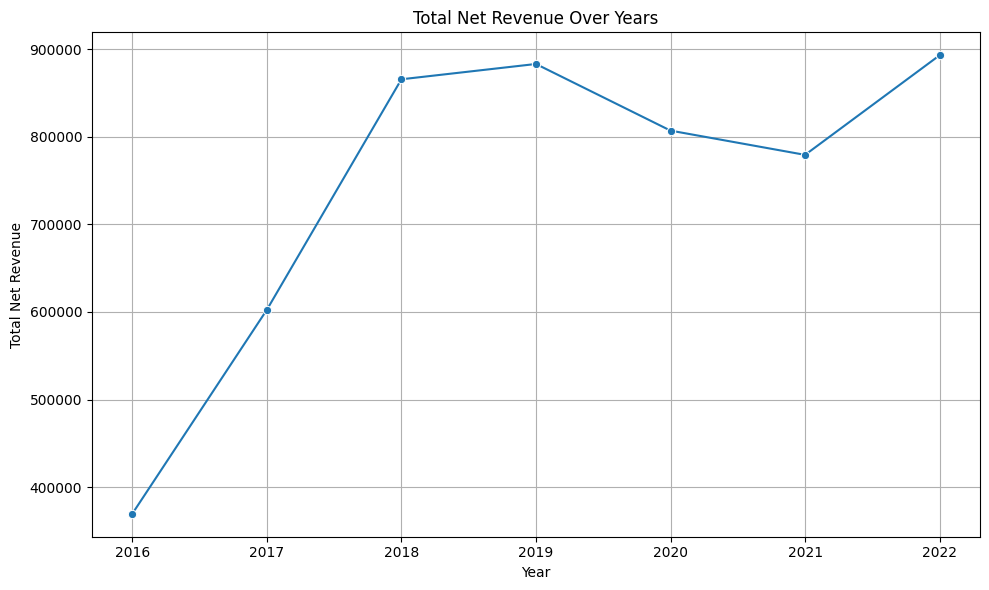

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'date' column to datetime objects if not already
sales_performance_df['date'] = pd.to_datetime(sales_performance_df['date'])

# Extract the year from the 'date' column
sales_performance_df['year'] = sales_performance_df['date'].dt.year

# Calculate total net revenue by year
revenue_by_year = sales_performance_df.groupby('year')['net_revenue'].sum().reset_index()

# Plotting the line graph
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='net_revenue', data=revenue_by_year, marker='o')
plt.title('Total Net Revenue Over Years')
plt.xlabel('Year')
plt.ylabel('Total Net Revenue')
plt.grid(True)
plt.xticks(revenue_by_year['year'].unique()) # Ensure all years are shown on x-axis
plt.tight_layout()
plt.show()

### 4. Category Performance Analysis

Now, let's analyze the performance of each product category by calculating the total `net_revenue` for each category. This will help us understand which categories are contributing the most to overall sales.

In [ ]:
revenue_by_category = sales_performance_df.groupby('category')['net_revenue'].sum().reset_index()

print("Total Net Revenue by Category:")
display(revenue_by_category.sort_values(by='net_revenue', ascending=False).style.format({
    'net_revenue': "${:,.2f}"
}))

Total Net Revenue by Category:


,category,net_revenue
6,Sports & Lifestyle,"$1,887,328.90"
0,Beauty,"$768,415.01"
1,Electronics Accessories,"$734,898.08"
3,Home & Living,"$538,241.24"
4,Home Care,"$529,700.90"
5,Personal Care,"$445,379.14"
2,Food & Beverage,"$295,721.78"


### 5. Net Revenue Comparison: Earliest 10 Weeks vs. Latest 10 Weeks by Channel

To analyze performance trends, let's compare the total net revenue for each channel during the earliest 10 weeks and the latest 10 weeks of the dataset. This will help us identify changes in channel performance over time.

In [ ]:
sales_performance_df['date'] = pd.to_datetime(sales_performance_df['date'])

sorted_sales_df = sales_performance_df.sort_values(by='date').reset_index(drop=True)

num_days_for_period = 70

earliest_dates = sorted_sales_df['date'].unique()[:num_days_for_period]
earliest_period_df = sorted_sales_df[sorted_sales_df['date'].isin(earliest_dates)]

latest_dates = sorted_sales_df['date'].unique()[-num_days_for_period:]
latest_period_df = sorted_sales_df[sorted_sales_df['date'].isin(latest_dates)]

revenue_early_period = earliest_period_df.groupby('channel')['net_revenue'].sum().reset_index()
revenue_early_period.rename(columns={'net_revenue': 'net_revenue_early_10_weeks'}, inplace=True)

revenue_latest_period = latest_period_df.groupby('channel')['net_revenue'].sum().reset_index()
revenue_latest_period.rename(columns={'net_revenue': 'net_revenue_latest_10_weeks'}, inplace=True)

comparison_df = pd.merge(revenue_early_period, revenue_latest_period, on='channel', how='outer')

comparison_df = comparison_df.fillna(0)

comparison_df['change'] = comparison_df['net_revenue_latest_10_weeks'] - comparison_df['net_revenue_early_10_weeks']
comparison_df['percentage_change'] = (comparison_df['change'] / comparison_df['net_revenue_early_10_weeks']) * 100
comparison_df['percentage_change'] = comparison_df['percentage_change'].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Comparison of Net Revenue by Channel (Earliest {num_days_for_period} days vs. Latest {num_days_for_period} days):")
display(comparison_df.sort_values(by='net_revenue_latest_10_weeks', ascending=False).style.format({
    'net_revenue_early_10_weeks': "${:,.2f}",
    'net_revenue_latest_10_weeks': "${:,.2f}",
    'change': "${:,.2f}",
    'percentage_change': "{:,.2f}%"
}))

Comparison of Net Revenue by Channel (Earliest 70 days vs. Latest 70 days):


,channel,net_revenue_early_10_weeks,net_revenue_latest_10_weeks,change,percentage_change
0,Amazon,"$23,246.45","$80,712.17","$57,465.72",247.20%
3,TikTokShop,"$14,177.88","$48,855.86","$34,677.98",244.59%
4,Zalora,"$8,684.73","$30,254.14","$21,569.41",248.36%
1,Retail_Flagship,"$7,380.78","$26,746.91","$19,366.13",262.39%
2,Retail_Kiosk,"$3,620.14","$17,643.96","$14,023.82",387.38%


### 6. Customer Segment Analysis: Total Net Revenue

To understand the financial contribution of different customer groups, let's calculate the total net revenue generated by each `customer_segment`.

In [ ]:
revenue_by_customer_segment = sales_performance_df.groupby('customer_segment')['net_revenue'].sum().reset_index()

print("Total Net Revenue by Customer Segment:")
display(revenue_by_customer_segment.sort_values(by='net_revenue', ascending=False).style.format({
    'net_revenue': "${:,.2f}"
}))

Total Net Revenue by Customer Segment:


,customer_segment,net_revenue
2,value,"$2,078,739.79"
0,budget,"$2,072,973.18"
1,premium,"$1,047,972.08"


### 6.2. Channel Preference by Customer Segment

Now, let's examine which sales channels are most popular for each customer segment based on net revenue.

In [ ]:
for segment in sales_performance_df['customer_segment'].unique():
    print(f"\n--- Channel Preference for {segment.title()} Segment ---")
    segment_df = sales_performance_df[sales_performance_df['customer_segment'] == segment]
    channel_preference_segment = segment_df.groupby('channel')['net_revenue'].sum().reset_index()
    display(channel_preference_segment.sort_values(by='net_revenue', ascending=False).style.format({
        'net_revenue': "${:,.2f}"
    }))


--- Channel Preference for Premium Segment ---


,channel,net_revenue
0,Amazon,"$419,078.50"
3,TikTokShop,"$257,509.53"
4,Zalora,"$150,504.25"
1,Retail_Flagship,"$136,993.39"
2,Retail_Kiosk,"$83,886.41"



--- Channel Preference for Value Segment ---


,channel,net_revenue
0,Amazon,"$826,264.45"
3,TikTokShop,"$519,285.47"
4,Zalora,"$297,869.27"
1,Retail_Flagship,"$278,560.52"
2,Retail_Kiosk,"$156,760.08"



--- Channel Preference for Budget Segment ---


,channel,net_revenue
0,Amazon,"$833,195.08"
3,TikTokShop,"$504,286.46"
4,Zalora,"$298,943.94"
1,Retail_Flagship,"$278,171.96"
2,Retail_Kiosk,"$158,375.74"
